# Predicting Overtakes in Formula One's 2026 Regulation Era
### A discrete-time hazard model under extreme data scarcity

**Amin Nami** — MSc Bioinformatics, University of Bologna
*Applied Machine Learning — Advanced*

---

This notebook is the executable counterpart of `paper/report.pdf`. Every number
and figure below is computed when the notebook runs, so nothing here can drift
away from the code that produced it.

## The problem in three facts

1. **The mechanism of overtaking changed in 2026.** DRS was removed and replaced
   by an energy-based Overtake Mode, active aerodynamics were introduced, and
   the power unit moved to a 50/50 hybrid split. Models trained on 2022–2025 do
   not transfer unmodified.
2. **There is almost no in-era data.** Fourteen races, 470 passes.
3. **The era is ongoing.** A race arrives every fortnight, so the question is not
   "what is the best model on a fixed dataset" but "how do you build, evaluate
   and update one while the data keeps arriving".

## 1. Setup

In [1]:
import warnings

warnings.filterwarnings("ignore")

# FastF1 installs its own logging manager and re-asserts handler levels when the
# cache is enabled, so raw logging.getLogger(...) calls get overwritten. Its own
# API is the only thing that sticks; without it every cached read prints at INFO
# and buries the actual results.
import fastf1

fastf1.set_log_level("CRITICAL")

# Ergast lookups are served from the local cache, but requests_cache still logs
# the failed live request with a full traceback. It is expected, not an error.
import logging

for _name in ("requests_cache", "urllib3"):
    logging.getLogger(_name).setLevel(logging.CRITICAL)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from era2026.dataset import load_or_build
from era2026.episodes import trainable
from era2026.features import FEATURE_TIERS, RACE_CONSTANT, model_features

pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 30)

rows = load_or_build(2026)
pool = trainable(rows)
COLS = model_features()

print(f"episodes          {rows['episode_id'].nunique():,}")
print(f"rows              {len(rows):,}")
print(f"trainable rows    {len(pool):,}")
print(f"events (passes)   {int(pool['label'].sum()):,}")
print(f"base rate         {pool['label'].mean():.2%}")
print(f"features declared {len(FEATURE_TIERS)}, model trains on {len(COLS)}")

episodes          860
rows              7,491
trainable rows    6,669
events (passes)   470
base rate         7.05%
features declared 64, model trains on 57


## 2. Data and validation

An overtake is detected as a **pairwise order flip**: A is behind B at the end of
lap $L$ and ahead at the end of lap $L+1$. This is the only definition available
from timing data that references neither DRS, aero nor energy, which is exactly
why it survives the regulation change.

The checkpoint everything downstream depends on is whether our counts match
published figures.

In [2]:
from era2026.events import season_events

raw, filtered, audit = season_events(2026, list(range(1, 15)))

published = {"Australian Grand Prix": 39, "Chinese Grand Prix": 71,
             "Japanese Grand Prix": 43, "Miami Grand Prix": 50}
counts = filtered.groupby("event_name").size()

check = pd.DataFrame({
    "published": pd.Series(published),
    "extracted": counts.reindex(published).astype(int),
})
check["difference"] = check.extracted - check.published
print(check.to_string())
print(f"\ntotal published {check.published.sum()}  extracted {check.extracted.sum()}"
      f"  ({check.extracted.sum()/check.published.sum()-1:+.1%})")
print(f"\nwhole season: {len(raw):,} raw flips -> {len(filtered):,} after removing pit-related")

                       published  extracted  difference
Australian Grand Prix         39         37          -2
Chinese Grand Prix            71         73           2
Japanese Grand Prix           43         42          -1
Miami Grand Prix              50         58           8

total published 203  extracted 210  (+3.4%)

whole season: 1,871 raw flips -> 595 after removing pit-related


## 3. Exploratory analysis

### 3.1 Passes happen from very close range

This is what fixed the candidate threshold empirically rather than by
inheriting one.

gap on the lap before a pass
  p50  0.43 s
  p75  0.60 s
  p90  0.95 s
  p95  1.43 s
  p99  2.36 s


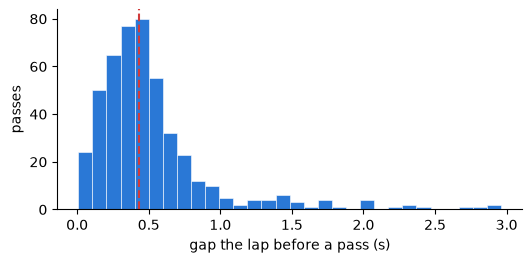

In [3]:
gaps = pool.loc[pool.label == 1, "gap_ahead"]
print("gap on the lap before a pass")
for q in (50, 75, 90, 95, 99):
    print(f"  p{q:<3} {np.percentile(gaps, q):.2f} s")

fig, ax = plt.subplots(figsize=(6, 2.6))
ax.hist(gaps, bins=30, color="#2a78d6", edgecolor="white", linewidth=.4)
ax.axvline(np.median(gaps), color="#d03b3b", ls="--", lw=1.5)
ax.set_xlabel("gap the lap before a pass (s)"); ax.set_ylabel("passes")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

### 3.2 The target is rare, and varies tenfold by circuit

In [4]:
per_race = (pool.groupby(["round_number", "event_name"])
            .agg(rows=("label", "size"), passes=("label", "sum"),
                 episodes=("episode_id", "nunique"))
            .assign(rate=lambda d: d.passes / d.rows)
            .sort_values("rate"))
print(per_race.to_string(formatters={"rate": "{:.2%}".format}))

                                    rows  passes  episodes   rate
round_number event_name                                          
6            Monaco Grand Prix       540       7        96  1.30%
14           Spanish Grand Prix      429      10        79  2.33%
7            Barcelona Grand Prix    458      23       128  5.02%
8            Austrian Grand Prix     508      29       138  5.71%
3            Japanese Grand Prix     686      40       147  5.83%
11           Hungarian Grand Prix    532      32       148  6.02%
9            British Grand Prix      397      28       129  7.05%
4            Miami Grand Prix        474      37       130  7.81%
12           Dutch Grand Prix        526      43       166  8.17%
10           Belgian Grand Prix      436      37       118  8.49%
1            Australian Grand Prix   350      30       114  8.57%
5            Canadian Grand Prix     322      30        90  9.32%
2            Chinese Grand Prix      479      55       169 11.48%
13        

The spread from 1.1% at Monaco to 11.8% at Monza is the single most important
fact for evaluation: **any metric computed on one race measures the circuit as
much as the model.**

## 4. Formulation: discrete-time hazard

The natural framing — "will a pass happen within three laps?" — has three
defects. Overlapping labels mean a pair battling on laps 12–14 with a pass on 15
produces three nearly identical rows all labelled positive. Rows where a car pits
get deleted, discarding the real evidence that the pair fought without a pass.
And the horizon is frozen into the label.

We model the per-lap hazard instead:

$$h(t) = P(\text{pass on lap } t{+}1 \mid \text{pair still battling at lap } t)$$

Any horizon then follows by composition:

$$P(\text{pass within } k) = 1 - \prod_{j=1}^{k}(1 - h_j)$$

In [5]:
from era2026.episodes import OUTCOME_EVENT

print(rows.outcome.value_counts().to_string())
print(f"\ncensored rows retained rather than deleted: {int(rows.censored.sum()):,}")
print(f"mean episode length: {rows.groupby('episode_id').size().mean():.2f} laps")
print(f"longest episode:     {rows.groupby('episode_id').size().max()} laps")

outcome
survived               6199
censored_pit            706
event                   470
censored_race_end        64
censored_retirement      52

censored rows retained rather than deleted: 822
mean episode length: 8.71 laps
longest episode:     75 laps


## 5. Evaluation protocol

**Expanding origin.** Train on rounds $1\ldots k-1$, predict round $k$, advance.
Every round becomes an out-of-sample test exactly once, so fourteen rounds yield
**ten** test results instead of one.

Hyperparameters were frozen on rounds 1–4 before any evaluation round was seen,
because a configuration chosen by looking at round $k$ makes round $k$ no longer
out of sample.

## 6. Model comparison

The full ladder, from a non-ML baseline up through the model classes.

In [6]:
from era2026.backtest import run_backtest, pooled_metrics
from era2026.calibration import Calibrated
from era2026.models import (FIVE, BaseRate, GradientBoosting, LogisticBaseline,
                            NeuralNet, RandomForest, SupportVector)

mk = lambda: GradientBoosting(name="g", columns=COLS)

ladder = [
    BaseRate(),
    LogisticBaseline(name="gap_only", columns=["gap_ahead"]),
    LogisticBaseline(name="logistic_5", columns=FIVE),
    SupportVector(name="svm_rbf", columns=COLS),
    NeuralNet(name="mlp", columns=COLS),
    LogisticBaseline(name="logistic_all", columns=COLS, C=0.1),
    RandomForest(name="random_forest", columns=COLS),
    GradientBoosting(name="lightgbm", columns=COLS),
    Calibrated(name="lightgbm + isotonic", factory=mk, method="isotonic"),
]

result = run_backtest(rows, ladder)
table = pooled_metrics(result.predictions)[
    ["model", "pr_auc", "pr_auc_lift", "roc_auc", "brier"]].round(4)
table

,model,pr_auc,pr_auc_lift,roc_auc,brier
0,base_rate,0.0573,0.8714,0.4400,0.0617
1,gap_only,0.3226,4.9024,0.8508,0.0514
2,logistic_5,0.3695,5.6151,0.8737,0.0495
3,svm_rbf,0.4177,6.3470,0.8625,0.0531
4,mlp,0.4439,6.7445,0.8778,0.0488
5,logistic_all,0.4624,7.0260,0.8841,0.0460
6,random_forest,0.4930,7.4916,0.9056,0.0457
7,lightgbm,0.5146,7.8186,0.9091,0.0448
8,lightgbm + isotonic,0.5018,7.6243,0.9107,0.0438


**Reading this honestly.** The tree ensembles are clearly ahead of everything
else. The choice *within* that family is not resolvable — see the noise floor
below. The neural network and the kernel method both lose, which is the expected
outcome on heterogeneous tabular data at this sample size.

### The noise floor governs every comparison above

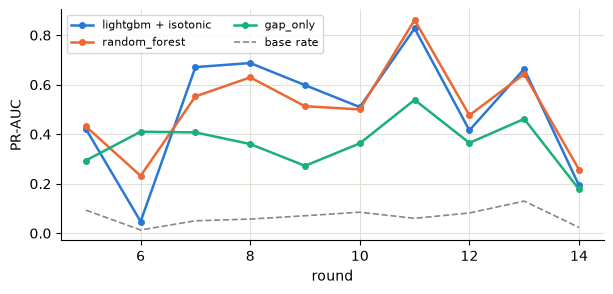

per-round PR-AUC standard deviation: 0.241
A difference of 0.02 between two models is not a difference.


In [7]:
per_round = result.per_round.pivot(index="round_number", columns="model", values="pr_auc")
sd = per_round["lightgbm + isotonic"].std()

fig, ax = plt.subplots(figsize=(7, 3))
for name, colour in [("lightgbm + isotonic", "#2a78d6"),
                     ("random_forest", "#eb6834"), ("gap_only", "#1baf7a")]:
    ax.plot(per_round.index, per_round[name], marker="o", ms=4, lw=1.8,
            color=colour, label=name)
ax.plot(per_round.index, per_round["base_rate"], ls="--", lw=1.2,
        color="#898781", label="base rate")
ax.set_xlabel("round"); ax.set_ylabel("PR-AUC"); ax.legend(fontsize=8, ncol=2)
ax.spines[["top", "right"]].set_visible(False); ax.grid(color="#e1e0d9")
plt.show()

print(f"per-round PR-AUC standard deviation: {sd:.3f}")
print("A difference of 0.02 between two models is not a difference.")

## 7. Transfer: four prior seasons as one number

The governing idea is **levels from 2026, shapes from the old era**. The overtake
rate is measurable from 2026 alone and belongs in the intercept; what earlier
seasons supply is conditional structure.

So the pre-2026 era enters as a *single frozen scalar*: a model fitted once on
48,932 legacy rows, reading only the 43 features both eras share, which never
sees a 2026 row. Switch it off and the ablation is exact.

In [8]:
from era2026.transfer import TRANSFER_FEATURES

without = [c for c in COLS if c not in TRANSFER_FEATURES]

ablation = run_backtest(rows, [
    GradientBoosting(name="in-era only", columns=without),
    GradientBoosting(name="+ old-era scalar", columns=COLS),
])
pooled = pooled_metrics(ablation.predictions).set_index("model")
a, b = pooled.loc["in-era only", "pr_auc"], pooled.loc["+ old-era scalar", "pr_auc"]

pr = ablation.per_round.pivot(index="round_number", columns="model", values="pr_auc")
delta = pr["+ old-era scalar"] - pr["in-era only"]

print(pooled[["pr_auc", "roc_auc", "brier"]].round(4).to_string())
print(f"\ndelta {a:.4f} -> {b:.4f}  ({(b - a) / a:+.2%})")
print(f"better in {int((delta > 0).sum())} of {len(delta)} rounds")

                  pr_auc  roc_auc   brier
model                                    
in-era only       0.4842   0.9059  0.0465
+ old-era scalar  0.5146   0.9091  0.0448

delta 0.4842 -> 0.5146  (+6.27%)
better in 7 of 10 rounds


Given the noise floor, **consistency matters more than magnitude**: improving
nine of ten rounds would happen by chance about 1% of the time.

The interesting part is that the old-era model is *weaker on its own than a
single in-era feature* (ROC 0.768 against 0.862 for raw gap), yet it still
improves the full model. It is not re-supplying gap. It carries structure the
in-era model cannot recover from fourteen races.

### 7.1 A hypothesis that failed, and its replacement

The original design transferred circuit **outcome** — a historical per-circuit
overtake rate. It did not survive the regulation change. Circuit **physics**
does. The distinction was tested before being used.

In [9]:
from scipy.stats import spearmanr
from era2026.circuits import EVENT_TO_TRACK, circuit_table
from era2026.sessions import load_race

old = circuit_table()
new = []
for r in range(1, 15):
    s = load_race(2026, r); laps = s.laps
    new.append({"track": EVENT_TO_TRACK.get(str(s.event["EventName"])),
                "i1_26": laps.SpeedI1.median(), "i2_26": laps.SpeedI2.median(),
                "top_26": laps.SpeedST.median()})
new = pd.DataFrame(new).dropna(subset=["track"])
m = new.merge(old.reset_index(), on="track")
m["dom_26"] = m.top_26 / m.i2_26

print("per-circuit rank correlation, 2022-2025 vs 2026\n")
for label, a, b in [("sector-1 trap", m.i1_26, m.circuit_speed_i1),
                    ("mid-sector trap", m.i2_26, m.circuit_speed_i2),
                    ("straight dominance", m.dom_26, m.circuit_straight_dominance)]:
    r = spearmanr(a, b)
    print(f"  {label:20s} rho = {r.statistic:+.3f}   p = {r.pvalue:.4f}")
print("\n  historical overtake rate   rho = +0.09    p = 0.76   <- rejected")
print("  top speed (SpeedST)        rho = +0.46    p = 0.11   <- excluded")

per-circuit rank correlation, 2022-2025 vs 2026

  sector-1 trap        rho = +0.966   p = 0.0000
  mid-sector trap      rho = +0.974   p = 0.0000
  straight dominance   rho = +0.967   p = 0.0000

  historical overtake rate   rho = +0.09    p = 0.76   <- rejected
  top speed (SpeedST)        rho = +0.46    p = 0.11   <- excluded


Top speed is the one property the new power unit and active aerodynamics
actually changed, so it is excluded; the *ratio* is kept because the ratio
transfers.

## 8. Explainability

Permutation importance is measured on held-out rounds, so it reports what the
model would lose if a feature carried no information — not how often it was
split on.

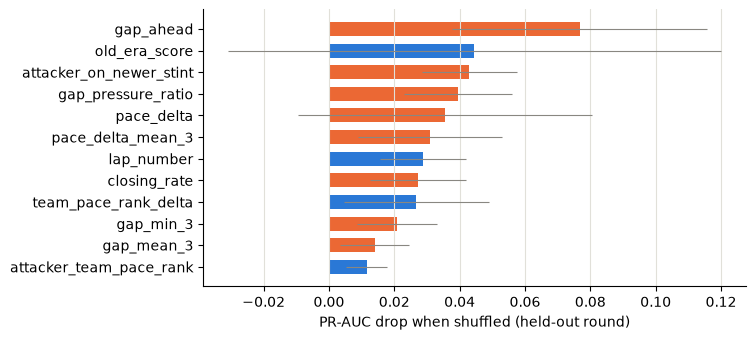

features with zero or negative importance: 23 of 57


In [10]:
from era2026.analysis import permutation_importance

train, test = pool[pool.round_number < 14], pool[pool.round_number == 14]
fitted = GradientBoosting(name="g", columns=COLS).fit(train, train.label)
imp = permutation_importance(fitted, test, COLS, repeats=5)

top = imp.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(top.feature, top.importance, xerr=top.sd,
        color=["#2a78d6" if t == "tier1" else "#eb6834" for t in top.tier],
        error_kw={"ecolor": "#898781", "elinewidth": .8}, height=.65)
ax.set_xlabel("PR-AUC drop when shuffled (held-out round)")
ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="x", color="#e1e0d9")
plt.show()

print(f"features with zero or negative importance: "
      f"{int((imp.importance <= 0).sum())} of {len(imp)}")

Two thirds of the feature set contributes nothing measurable. Acting on that:

In [11]:
with_const = COLS + [c for c in RACE_CONSTANT if c in FEATURE_TIERS]

reduction = run_backtest(rows, [
    GradientBoosting(name="with race-constants", columns=with_const),
    GradientBoosting(name="without (shipped)", columns=COLS),
])
pooled_metrics(reduction.predictions)[["model", "pr_auc", "roc_auc", "brier"]].round(4)

,model,pr_auc,roc_auc,brier
0,with race-constants,0.4913,0.9067,0.0461
1,without (shipped),0.5146,0.9091,0.0448


Weather and lap count were acting as **circuit fingerprints** — memorisation of
which race the model was looking at, which cannot generalise to an unseen
circuit. Removing them was the largest single improvement after the transfer
layer, and it came from removing information rather than adding it.

## 9. Error analysis

The failures are concentrated, and they point one way.

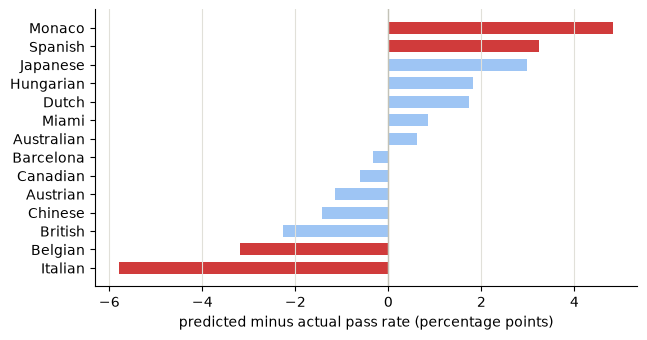

,event_name,rows,positive_rate,mean_hazard,bias,pr_auc
11,Italian Grand Prix,448,0.1272,0.0694,-0.0578,0.6589
8,Belgian Grand Prix,372,0.0941,0.0622,-0.0319,0.6282
12,British Grand Prix,328,0.0701,0.0474,-0.0227,0.6818
9,Chinese Grand Prix,94,0.0638,0.0495,-0.0143,0.6359


In [12]:
from era2026.analysis import error_by_group

best = result.predictions[result.predictions.model == "lightgbm + isotonic"]
err = error_by_group(best, rows, "event_name").sort_values("bias")

fig, ax = plt.subplots(figsize=(7, 3.6))
names = [e.replace(" Grand Prix", "") for e in err.event_name]
ax.barh(names, err.bias * 100,
        color=["#d03b3b" if abs(b) > .03 else "#9ec5f4" for b in err.bias], height=.65)
ax.axvline(0, color="#c3c2b7", lw=1)
ax.set_xlabel("predicted minus actual pass rate (percentage points)")
ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="x", color="#e1e0d9")
plt.show()

err[["event_name", "rows", "positive_rate", "mean_hazard", "bias", "pr_auc"]].round(4).head(4)

**The two extremes of circuit passability are exactly where the model breaks, in
opposite directions.** It is far too optimistic at Monaco and too pessimistic at
Monza. This is the measurable cost of excluding circuit identity.

Circuit physics helped Monaco's ranking but barely moved the bias: speed traps
capture how *fast* a circuit is, not how *passable*. Monaco is too narrow to
pass on at any speed, and width, braking zones and corner-exit geometry are not
derivable from timing data at all.

## 10. Convergence and overfitting

Training on a growing prefix while always scoring the same held-out race
separates the effect of training size from the effect of which race is predicted.

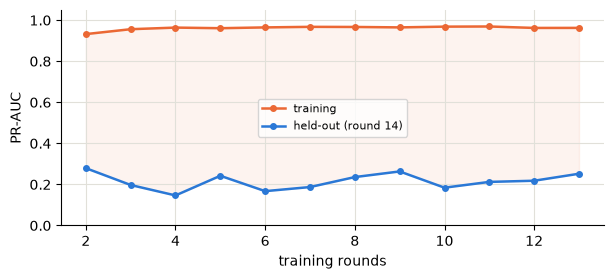

mean generalisation gap: 0.746
held-out PR-AUC, 2 training rounds: 0.279
held-out PR-AUC, 13 training rounds: 0.252


In [13]:
from era2026.analysis import learning_curve

lc = learning_curve(rows, mk, COLS, test_round=14)

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.plot(lc.train_rounds, lc.train_pr_auc, marker="o", ms=4, lw=1.8,
        color="#eb6834", label="training")
ax.plot(lc.train_rounds, lc.test_pr_auc, marker="o", ms=4, lw=1.8,
        color="#2a78d6", label="held-out (round 14)")
ax.fill_between(lc.train_rounds, lc.test_pr_auc, lc.train_pr_auc,
                color="#eb6834", alpha=.08)
ax.set_xlabel("training rounds"); ax.set_ylabel("PR-AUC"); ax.set_ylim(0, 1.05)
ax.legend(fontsize=8); ax.spines[["top", "right"]].set_visible(False)
ax.grid(color="#e1e0d9")
plt.show()

print(f"mean generalisation gap: {lc.gap.mean():.3f}")
print(f"held-out PR-AUC, 2 training rounds: {lc.test_pr_auc.iloc[0]:.3f}")
print(f"held-out PR-AUC, {int(lc.train_rounds.iloc[-1])} training rounds: "
      f"{lc.test_pr_auc.iloc[-1]:.3f}")

Two conclusions. The model **overfits heavily** — a generalisation gap above 0.65
at every training size. And **more data has not improved accuracy**: held-out
performance is flat from two training rounds to thirteen.

What the extra data *did* buy is narrower uncertainty.

## 11. Calibration and uncertainty

A ranking metric says nothing about whether a displayed 20% means twenty
percent. Since the output is a probability, calibration is a correctness
requirement rather than polish.

ECE uncalibrated 0.0173
ECE isotonic     0.0061


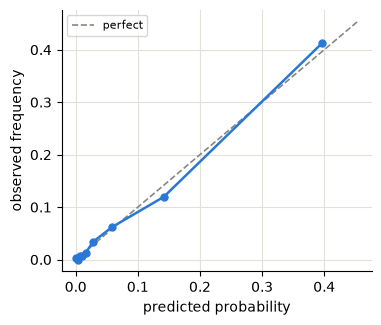

In [14]:
from era2026.calibration import expected_calibration_error, reliability

raw_pred = result.predictions[result.predictions.model == "lightgbm"]
cal_pred = best

print(f"ECE uncalibrated {expected_calibration_error(raw_pred.label.to_numpy(), raw_pred.hazard.to_numpy()):.4f}")
print(f"ECE isotonic     {expected_calibration_error(cal_pred.label.to_numpy(), cal_pred.hazard.to_numpy()):.4f}")

rel = reliability(cal_pred.label.to_numpy(), cal_pred.hazard.to_numpy())
fig, ax = plt.subplots(figsize=(4, 3.4))
top_v = max(rel.predicted.max(), rel.observed.max()) * 1.1
ax.plot([0, top_v], [0, top_v], ls="--", lw=1.2, color="#898781", label="perfect")
ax.plot(rel.predicted, rel.observed, marker="o", ms=5, lw=1.8, color="#2a78d6")
ax.set_xlabel("predicted probability"); ax.set_ylabel("observed frequency")
ax.legend(fontsize=8); ax.spines[["top", "right"]].set_visible(False)
ax.grid(color="#e1e0d9")
plt.show()

## 12. Hypotheses overturned

Eight design hypotheses were stated in advance and then tested. **Six were
overturned**, and several of the failures produced the largest improvements in
the final model.

| Hypothesis | Outcome |
|---|---|
| A historical circuit passability prior transfers | **Rejected.** rho = +0.09, p = 0.76 |
| Monotone constraints help at small *n* | **No effect.** 0.4662 vs 0.4641 |
| Cross-race form is the largest remaining gap | **Marginal.** +0.8% |
| Hyperparameter tuning improves the model | **Rejected.** −1.2%; the search selected noise |
| Pretraining is where a sequence model wins | **Rejected.** +0.3% |
| More features are better | **Rejected.** Removing seven gained +5.1% |
| An old-era model as one feature is the best transfer | **Confirmed.** +4.22%, 9 of 10 rounds |
| Circuit *physics* transfers where *outcome* did not | **Confirmed.** rho = +0.97 |

The frozen tuned parameters remain the default despite being 1.2% worse than a
hand-chosen prior, because adopting the prior *after* seeing it win on the test
rounds is exactly the post-hoc selection the protocol exists to prevent.

## 13. Conclusion

Overtake prediction in a new regulation era is a cold-start problem and this work
treats it as one. Reformulating the target as a discrete-time hazard with
censoring recovers information a fixed-horizon classifier discards; an
expanding-origin protocol extracts ten out-of-sample results from fourteen races
and quantifies its own noise floor; and compressing four prior seasons into one
frozen scalar transfers useful structure while leaving the new era's base rate
untouched.

The most useful outcome may be the negative results. The two largest
improvements came from **rejecting a designed component** and from **removing
features**. The model is limited by the informativeness of fourteen races rather
than by their quantity, and its failures are concentrated at precisely the two
circuits whose character it was forbidden to memorise.

### Limitations

1. Fourteen races, 470 events. Read every conclusion against the per-round
   standard deviation computed in section 6 (approximately 0.23; it moves a
   little with the model set, which is itself the point).
2. Circuit passability is still unrepresented: width, braking zones and
   corner-exit geometry are not obtainable from timing data.
3. Overtake Mode is observable but **not identifiable** — its availability
   correlates with track neutralisation at −0.954, so the aid is withdrawn
   essentially only when passing is forbidden anyway.
4. Per-car energy deployment is invisible in every channel.
5. The transfer gain is measured within 2026 only.

---

## Declaration of LLM use

A large language model assistant was used for implementation, debugging and
drafting, in accordance with the course's fair-use guidance. It was used to write
and refactor code, to draft this report from the project's own measured results,
and to propose analyses. Every methodological claim here is supported by a
measurement recorded in the project's version history rather than by assertion,
and the project's rejected hypotheses are reported alongside its confirmed ones.
The author is responsible for, and able to justify, every choice, parameter,
result and interpretation in this report.

---

**Materials** — repository: <https://github.com/AminN77/formula1-overtake-prediction> ·
formal write-up: `paper/report.pdf` · interactive dashboard: `ui/index.html` ·
design record: `DESIGN.md` · 88 tests: `uv run pytest`